# PROC OPTMODEL로 잡숍(Job-Shop)의 메이크스팬(Makespan) 최소화하기


## 요약

소규모 이산 제조 셀에서 네 개의 부품 — **브래킷**, **플랜지**, **하우징**, **샤프트** — 을 각각 세 개의 정해진 가공 공정 순서를 따라 통과시켜야 하며, 이 부품들은 단일 용량 기계 네 대(**톱**, **밀링**, **드릴**, **연삭**)를 공유합니다. 어떤 기계도 두 공정을 동시에 실행할 수 없고, 각 부품의 공정은 기술적 순서를 반드시 지켜야 합니다. 우리는 메이크스팬을 최소화하는 스케줄을 **PROC OPTMODEL**의 혼합정수계획(mixed-integer program)으로 정식화합니다 — 시작 시각 변수, 종료-대-시작(finish-to-start) 선후 관계 제약, 그리고 기계를 공유하는 모든 공정 쌍 사이의 논리합형(disjunctive, big-*M*) 비중첩 제약 — 그리고 이를 증명된 최적성(proven optimality)까지 풀어냅니다.

MILP 솔버는 **최적 메이크스팬 120분**을 반환합니다(`Solution Status = Optimal`, `Objective Value = 120`). 얻어진 스케줄은 열두 개 공정 전부를 배치하되, 모든 기계가 한 번에 최대 한 부품만 처리하고, 각 부품이 요구되는 기술적 순서대로 가공되도록 합니다. 두 공정이 정확히 120분에 끝납니다 — 하우징의 밀링과 브래킷의 연삭 — 따라서 밀링과 연삭 기계 모두 스케줄 길이를 결정짓는 임계 경로(critical path) 위에 놓입니다.

## 데이터 출처

모든 데이터는 노트북 내부에서 정의됩니다 — 외부 파일이나 네트워크가 없습니다.

| 데이터셋 | 행 수 | 주요 변수 | 설명 |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | 공정당 한 행(부품 4개 × 공정 3개). `machine`(1–4)은 공정이 필요로 하는 기계이고, `dur`은 분 단위 처리 시간이며, `jobname`/`mname`은 읽기 쉬운 부품 및 기계 라벨입니다. |
| `sched` | 12 | `op`, `start`, `finish` | OPTMODEL 출력: 모든 공정의 최적 시작 분과 종료 분. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop`을 풀린 시각과 병합하고, 기계 순 그다음 시작 시각 순으로 정렬한 것 — 사람이 읽을 수 있는 스케줄. |
| `mk` | 1 | `makespan` | 실현된 메이크스팬(가장 늦은 종료 시각). |


## 스케줄링 문제

**잡숍(job shop)**에서는 여러 부품("작업(job)")이 각각 정해진 공정 순서를 통과하고, 모든 공정은 특정 기계에서 실행됩니다. 두 공정은 같은 기계를 동시에 점유할 수 없으며(기계는 *단항(unary)* 자원입니다), 한 부품 안에서 공정들은 기술적 순서를 지켜야 합니다. 계획자는 이 두 규칙을 모두 준수하면서 전체 스케줄 길이 — **메이크스팬(makespan)** — 을 가능한 한 작게 유지하는, 모든 공정의 시작 시각을 원합니다.

이는 고전적인 논리합형 스케줄링 문제입니다. 우리는 이를 혼합정수계획으로 모델링합니다:

- 각 공정에 대한 연속이지만 정수인 **시작 시각** `s[o]`와 메이크스팬 변수 `Cmax`;
- **선후 관계(precedence)**: 부품의 *k+1*번째 공정은 *k*번째 공정이 끝나는 시각보다 일찍 시작하지 않습니다;
- **논리합형 기계 용량(disjunctive machine capacity)**: 기계를 공유하는 각 공정 쌍에 대해, 이진 변수 `y`가 어느 쪽이 먼저 갈지 결정하고, big-*M* 항이 비활성 순서를 꺼서 — 두 공정이 결코 겹치지 않도록 합니다;
- **목적(objective)**: `Cmax`를 최소화하며, `Cmax`는 모든 공정의 종료 시각 이상이 되도록 강제됩니다.

PROC OPTMODEL은 SAS/OR의 대수적 모델링 프로시저입니다. 그 MILP 솔버는 *증명 가능하게 최적인(provably optimal)* 최단 스케줄을 찾습니다.

> **PROC CLP에 관한 참고.** SAS는 PROC CLP도 제공하는데, 이는 전용 스케줄링 문법(활동, > 자원, 선후 관계)을 갖춘 제약 논리 > 프로그래밍(constraint-logic programming) 엔진입니다. 여기의 OPTMODEL MILP 정식화는 > 동일한 문제를 풀며 최적성 인증서(certificate of optimality)를 반환하는데, 이는 CLP의 > 실행가능성 탐색(feasibility search)이 제공하지 않는 것입니다.


## 1단계 — 숍 인스턴스 정의

네 개 부품, 각각 세 개 공정, 네 대 기계 위에서. 각 행은 공정이 필요로 하는 기계와 분 단위 처리 시간을 고정합니다. 한 부품의 공정들은 기술적 순서(`opnum` 1, 2, 3)로 나열됩니다.


In [1]:
데이터 jobshop;
    길이 jobname $12 mname $9;
    입력 op job opnum machine dur jobname $ mname $;
    자료;
1  1 1 1 25 브래킷  톱
2  1 2 3 40 브래킷  드릴
3  1 3 4 20 브래킷  연삭
4  2 1 2 35 플랜지  밀링
5  2 2 3 25 플랜지  드릴
6  2 3 1 15 플랜지  톱
7  3 1 3 30 하우징  드릴
8  3 2 1 20 하우징  톱
9  3 3 2 45 하우징  밀링
10 4 1 1 20 샤프트  톱
11 4 2 2 30 샤프트  밀링
12 4 3 4 25 샤프트  연삭
;
실행;

처리 인쇄 데이터=jobshop noobs;
    제목 '잡숍 인스턴스: 부품 4개, 각 공정 3개, 기계 4대';
    변수 op jobname opnum mname dur;
    라벨 op="공정" jobname="부품" opnum="공정번호" mname="기계" dur="소요시간(분)";
실행;

                                             잡숍 인스턴스: 부품 4개, 각 공정 3개, 기계 4대                                             

    공정         부품          공정번호      기계            소요시간(분)
     1  브래킷                   1  톱                      25
     2  브래킷                   2  드릴                     40
     3  브래킷                   3  연삭                     20
     4  플랜지                   1  밀링                     35
     5  플랜지                   2  드릴                     25
     6  플랜지                   3  톱                      15
     7  하우징                   1  드릴                     30
     8  하우징                   2  톱                      20
     9  하우징                   3  밀링                     45
    10  샤프트                   1  톱                      20
    11  샤프트                   2  밀링                     30
    12  샤프트                   3  연삭                     25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## 2단계 — PROC OPTMODEL로 메이크스팬 최소화 스케줄 풀기

OPTMODEL은 인스턴스를 읽고, 시작 시각 변수와 순서 변수를 만들고, 선후 관계 및 논리합형 제약을 등록한 뒤, MILP 솔버로 메이크스팬을 최소화합니다. big-*M* 지평선 `H`는 총 작업량으로, 모든 시작 시각에 대한 안전한 상한입니다. 솔버는 **최적(optimal)** 목적값을 보고합니다. 우리는 선택된 시작 및 종료 시각을 `sched`에 기록합니다.


In [2]:
처리 optmodel;
    설정 OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ 데이터 jobshop INTO OPS=[op] job opnum machine dur;

    /* 안전한 big-M 지평선 = 총 작업량 */
    num H = sum{o IN OPS} dur[o];

    변수 s{OPS} >= 0 integer;     /* 공정 시작 시각(분) */
    변수 Cmax >= 0;               /* 메이크스팬 */

    /* 기술적 순서: 공정 k+1은 공정 k가 끝난 뒤 시작 */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] 그리고 opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* 메이크스팬은 모든 공정의 종료 시각을 지배 */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* 논리합형 기계 용량: 기계를 공유하는 각 공정 쌍에 대해,
       이진 y가 순서를 고정하고 big-M이 다른 쪽을 완화 */
    변수 y{a IN OPS, b IN OPS:
          a < b 그리고 machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b 그리고 machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b 그리고 machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE 데이터 sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                                             잡숍 인스턴스: 부품 4개, 각 공정 3개, 기계 4대                                             


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 3단계 — 읽기 쉬운 스케줄 조립

풀린 시각을 부품 및 기계 라벨에 다시 병합하고, 기계 순 그다음 시작 시각 순으로 정렬한 뒤 스케줄을 출력합니다. 메이크스팬은 모든 공정에 걸친 가장 큰 종료 시각입니다.


In [3]:
처리 정렬 데이터=jobshop out=jobs2; 기준 op; 실행;
처리 정렬 데이터=sched   out=sol;   기준 op; 실행;

데이터 schedule;
    결합 jobs2 sol;
    기준 op;
실행;

처리 정렬 데이터=schedule; 기준 mname START; 실행;

처리 인쇄 데이터=schedule noobs;
    제목 '최적 스케줄: 모든 공정의 시작 / 종료 (분)';
    변수 jobname opnum mname dur START FINISH;
    라벨 jobname="부품" opnum="공정번호" mname="기계" dur="소요시간(분)"
          START="시작" FINISH="종료";
실행;

처리 평균 데이터=schedule MAX NOPRINT;
    변수 FINISH;
    출력 out=mk(제거=_type_ _freq_) MAX=makespan;
실행;

처리 인쇄 데이터=mk noobs;
    제목 '최소 메이크스팬 (가장 늦은 공정 종료, 분)';
    라벨 makespan="메이크스팬";
실행;

                                               최적 스케줄: 모든 공정의 시작 / 종료 (분)                                               

       부품          공정번호      기계            소요시간(분)      시작      종료
하우징                   1  드릴                     30       0      30
플랜지                   2  드릴                     25      35      60
브래킷                   2  드릴                     40      60     100
플랜지                   1  밀링                     35       0      35
샤프트                   2  밀링                     30      35      65
하우징                   3  밀링                     45      75     120
샤프트                   3  연삭                     25      65      90
브래킷                   3  연삭                     20     100     120
샤프트                   1  톱                      20       0      20
브래킷                   1  톱                      25      20      45
하우징                   2  톱                      20      45      65
플랜지                   3  톱                      15      65      80

      


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## 4단계 — 스케줄 시각화

각 공정에 서수 **슬롯(slot)**(기계 순, 그다음 시작 순으로 정렬)을 부여하고 그 시간 창을 떠 있는 막대(floating bar)로 그립니다: 막대는 공정의 시작 분부터 종료 분까지 걸칩니다. 슬롯 1–3은 드릴, 4–6은 밀링, 7–8은 연삭, 9–12는 톱입니다. 바로 아래 표는 각 슬롯의 부품을 명시하므로, 차트와 표를 함께 읽을 수 있습니다. 같은 기계의 막대들은 시간상 결코 겹치지 않습니다 — 논리합형 제약이 시각적으로 드러난 것입니다.

                                               슬롯별 스케줄 (슬롯 순서는 아래 차트와 일치)                                               

    슬롯      기계         부품      시작      종료
     1  드릴      하우징             0      30
     2  드릴      플랜지            35      60
     3  드릴      브래킷            60     100
     4  밀링      플랜지             0      35
     5  밀링      샤프트            35      65
     6  밀링      하우징            75     120
     7  연삭      샤프트            65      90
     8  연삭      브래킷           100     120
     9  톱       샤프트             0      20
    10  톱       브래킷            20      45
    11  톱       하우징            45      65
    12  톱       플랜지            65      80

                                               슬롯별 스케줄 (슬롯 순서는 아래 차트와 일치)                                               




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


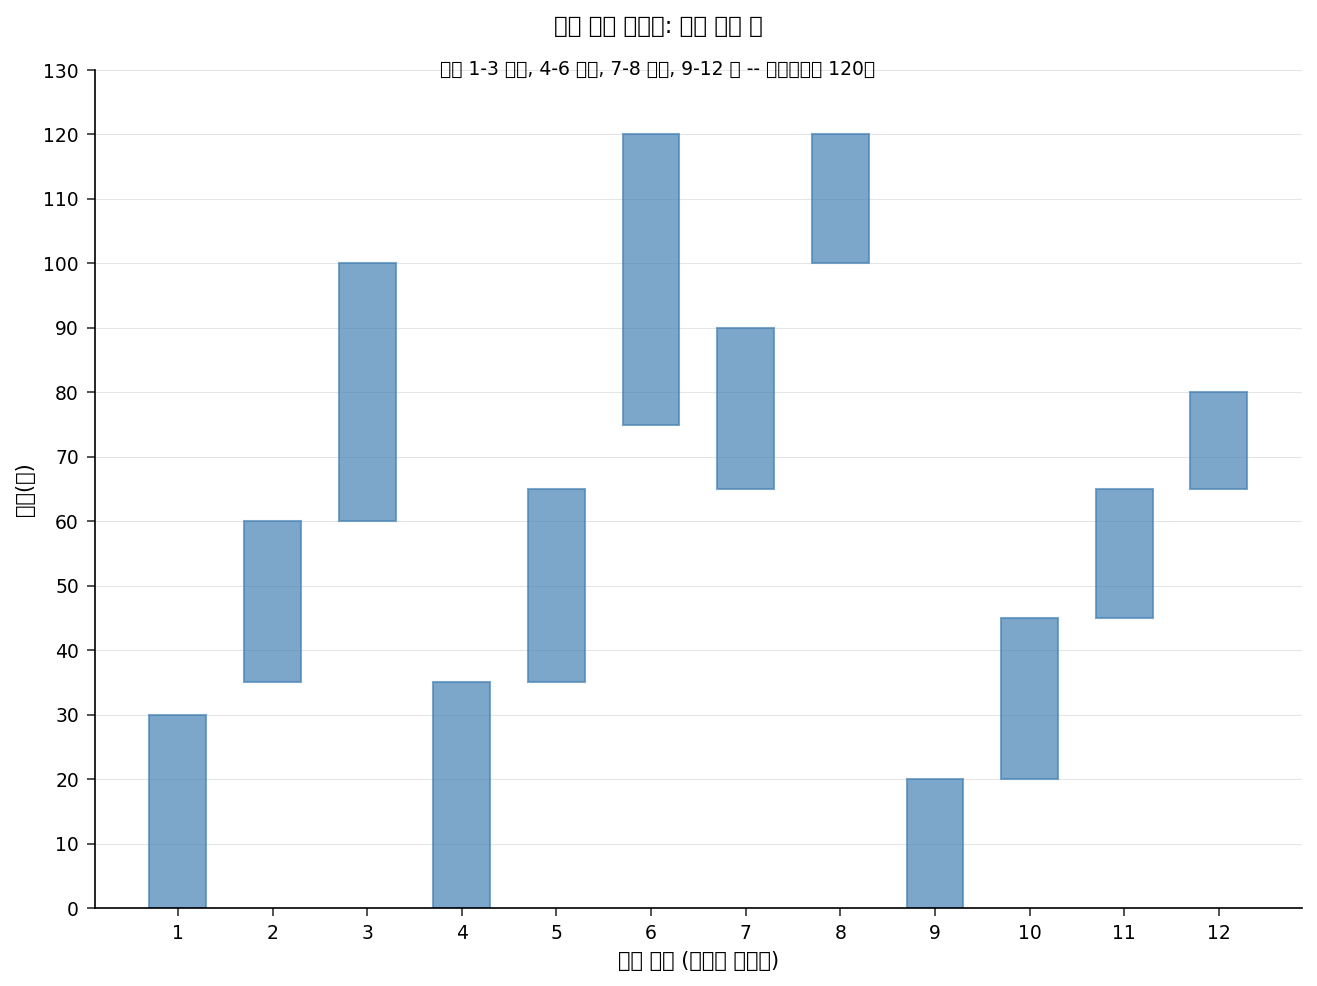

In [4]:
데이터 ganttdata;
    설정 schedule;
    slot + 1;
실행;

처리 인쇄 데이터=ganttdata noobs;
    제목 '슬롯별 스케줄 (슬롯 순서는 아래 차트와 일치)';
    변수 slot mname jobname START FINISH;
    라벨 slot="슬롯" mname="기계" jobname="부품" START="시작" FINISH="종료";
실행;

처리 SGPLOT 데이터=ganttdata noautolegend;
    제목 '최적 잡숍 스케줄: 공정 시간 창';
    title2 '슬롯 1-3 드릴, 4-6 밀링, 7-8 연삭, 9-12 톱 -- 메이크스팬 120분';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS 라벨='공정 슬롯 (기계별 그룹화)' integer
          VALUES=(1 까지 12 기준 1);
    YAXIS 라벨='시간(분)' grid VALUES=(0 까지 130 기준 10);
실행;
제목;

## 결과 해석

- **최적성.** MILP 솔버는 `Solution Status = Optimal`과 `Objective Value = 120`을 반환했으므로, **120분은 이 인스턴스에 대해 증명 가능하게 가장 짧은 메이크스팬**입니다 — 어떤 스케줄도 더 일찍 끝날 수 없습니다. 이 인증서야말로 순수 실행가능성 탐색 대비 수리계획 정식화가 안겨주는 가치입니다.

- **스케줄은 모든 제약을 준수합니다.** 기계별 표를 읽으면, 같은 기계에서 두 공정이 겹치지 않고(예: 톱 위에서: 샤프트 0–20, 브래킷 20–45, 하우징 45–65, 플랜지 65–80), 각 부품은 기술적 순서로 실행됩니다(예: 하우징: 드릴 0–30, 이어서 톱 45–65, 그다음 밀링 75–120). 떠 있는 막대 차트도 동일한 것을 보여줍니다: 각 기계의 슬롯 대역 안에서 시간 창들이 충돌 없이 타일처럼 맞물립니다.

- **스케줄 길이를 결정하는 것.** 두 공정이 정확히 120분에 끝납니다 — 하우징의 밀링(슬롯 6)과 브래킷의 연삭(슬롯 8). 둘 다 메이크스팬에 닿으므로 밀링과 연삭 기계는 임계 경로에 놓입니다. 메이크스팬을 더 줄이려면 단순히 순서를 재배치하는 것이 아니라 인스턴스 자체를 바꿔야 합니다(더 빠른 공정, 추가 기계, 또는 완화된 선후 관계).

- **확장성.** 이 정식화는 자연스럽게 커집니다: `machine`의 또 다른 값으로 기계를 추가하고, `jobshop`에 행을 더 넣어 부품을 추가하며, `s[o]`를 제한하고 납기 제약을 추가해 출시일과 납기일을 모델링합니다. 한 기계가 여러 작업을 동시에 실행하도록 허용하면(용량 >1) 쌍별 논리합이 누적 자원(cumulative-resource) 제약으로 대체됩니다. 그러면 동일한 OPTMODEL MILP가 솔버를 바꾸지 않고도 더 풍부한 작업 현장 규칙을 처리합니다.